In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, auc, f1_score, matthews_corrcoef
from sklearn.model_selection import train_test_split

from rapidgbm import RapidGBMTuner

import glob
import mplhep as hep
hep.style.use([hep.style.ATLAS])
import pickle

import uproot

In [3]:
filepath = '/groups/hep/kinch/data/preprocessed_data/files_from_grid/user.amoranch.ggZH125_Zllgamma_602896_H2Zy_13Nov_hist/user.amoranch.42061378._000001.hist-output.root'
cut = 0.5655481224483226
fp2cut = 0.002438322736013401


# Load the data

# check if parquet file already exists
if os.path.exists(f'{filepath[:-5]}.parquet'):
    data_ggZH = pd.read_parquet(f'{filepath[:-5]}.parquet')
else:
    ggZH_file = uproot.open(filepath)
    ggZH_data = ggZH_file['HZG_Tree']
    data_ggZH = pd.DataFrame.from_dict({key: ggZH_data[key].array() for key in ggZH_data.keys()})
    data_ggZH.to_parquet(f'{filepath[:-5]}.parquet')

data_ggZH = data_ggZH[data_ggZH['EventInfo.channel']==1]

filepath = '/groups/hep/kinch/data/preprocessed_data/files_from_grid/user.amoranch.ZH125J_Zllgamma_602893_H2Zy_13Nov_hist/user.amoranch.42061409._000001.hist-output.root'

# check if parquet file already exists
if os.path.exists(f'{filepath[:-5]}.parquet'):
    data_ZH = pd.read_parquet(f'{filepath[:-5]}.parquet')
else:
    ZH_file = uproot.open(filepath)
    ZH_data = ZH_file['HZG_Tree']
    data_ZH = pd.DataFrame.from_dict({key: ZH_data[key].array() for key in ZH_data.keys()})
    data_ZH.to_parquet(f'{filepath[:-5]}.parquet')

data_ZH = data_ZH[data_ZH['EventInfo.channel']==1]


In [4]:
from_z_bool = (data_ZH['l1_truthOrigin'] == 13) & (data_ZH['l2_truthOrigin'] == 13) & (data_ZH['l1_truthPdgId'] * data_ZH['l2_truthPdgId'] == -121)

data_ZH['truth_from_Z'] = from_z_bool

from_z_bool = (data_ggZH['l1_truthOrigin'] == 13) & (data_ggZH['l2_truthOrigin'] == 13) & (data_ggZH['l1_truthPdgId'] * data_ggZH['l2_truthPdgId'] == -121)

data_ggZH['truth_from_Z'] = from_z_bool

In [5]:
print(data_ZH.shape[0], data_ggZH.shape[0], data_ZH.shape[0] + data_ggZH.shape[0])

103249 135902 239151


In [6]:
iso_param_list = ['m_lx_ptcone20', 'm_lx_ptcone20_pt1000', 'm_lx_ptcone20_pt500', 'm_lx_ptcone30',
                  'm_lx_ptvarcone20', 'm_lx_ptvarcone30', 'm_lx_ptvarcone30_pt1000', 'm_lx_ptvarcone30_pt500',
                  'm_lx_topoetcone20', 'm_lx_topoetcone20ptCorrection', 'm_lx_topoetcone40', 'm_lx_neflowisol20']

iso_1_param_list = ['l1_ptcone20', 'l1_ptcone20_pt1000', 'l1_ptcone20_pt500', 'l1_ptcone30',
                    'l1_ptvarcone20', 'l1_ptvarcone30', 'l1_ptvarcone30_pt1000', 'l1_ptvarcone30_pt500',
                    'l1_topoetcone20', 'l1_topoetcone20ptCorrection', 'l1_topoetcone40', 'l1_neflowisol20']

iso_2_param_list = ['l2_ptcone20', 'l2_ptcone20_pt1000', 'l2_ptcone20_pt500', 'l2_ptcone30',
                    'l2_ptvarcone20', 'l2_ptvarcone30', 'l2_ptvarcone30_pt1000', 'l2_ptvarcone30_pt500',
                    'l2_topoetcone20', 'l2_topoetcone20ptCorrection', 'l2_topoetcone40', 'l2_neflowisol20']

pred_z_param_list = ['l1_iso_score', 'l2_iso_score', 
                     'l1_DNN_pel', 'l1_z0', 'l1_sig_z0', 'l2_DNN_pel', 'l2_z0', 'l2_sig_z0', 'EventInfo.actualIntPerXing'
                     , 'EventInfo.averageIntPerXing', 'EventInfo.mu']

others = ['EventInfo.eventNumber', 'truth_from_Z', 'EventInfo.cutflow', 'EventInfo.cutflow_new', 'll_m', 'type']

param_list = iso_1_param_list + iso_2_param_list + pred_z_param_list[2:] + others

print(f'data_ggZH shape: {data_ggZH.shape}, data_ZH shape: {data_ZH.shape}')




data_ggZH = data_ggZH[param_list[:-1]]
data_ZH = data_ZH[param_list[:-1]]

print(f'data_ggZH shape: {data_ggZH.shape}, data_ZH shape: {data_ZH.shape}')

data_ggZH['type'] = 'ggZH'
data_ZH['type'] = 'ZH'
Data = pd.concat([data_ggZH, data_ZH])

Data = Data[param_list]

iso1 = np.zeros(Data.shape[0])
iso2 = np.zeros(Data.shape[0])

print(Data.shape)
print(iso1.shape)

data_ggZH shape: (135902, 443), data_ZH shape: (103249, 443)
data_ggZH shape: (135902, 38), data_ZH shape: (103249, 38)
(239151, 39)
(239151,)


In [7]:
for i in range(4):
    with open(f'iso_tuner_{i}.pkl', 'rb') as f:
        tuner = pickle.load(f)
    mask = Data['EventInfo.eventNumber'] % 4 == i
    X_test_1 = Data[mask][iso_1_param_list]
    X_test_2 = Data[mask][iso_2_param_list]
    iso1[mask] = tuner.predict_proba(X_test_1)
    iso2[mask] = tuner.predict_proba(X_test_2)

Data['l1_iso_score'] = iso1
Data['l2_iso_score'] = iso2

In [8]:

with open('z_tuner_noncross.pkl', 'rb') as f:
    tuner = pickle.load(f)

score = np.zeros(Data.shape[0])
score = tuner.predict_proba(Data[pred_z_param_list])

Text(1, 0, 'Z score')

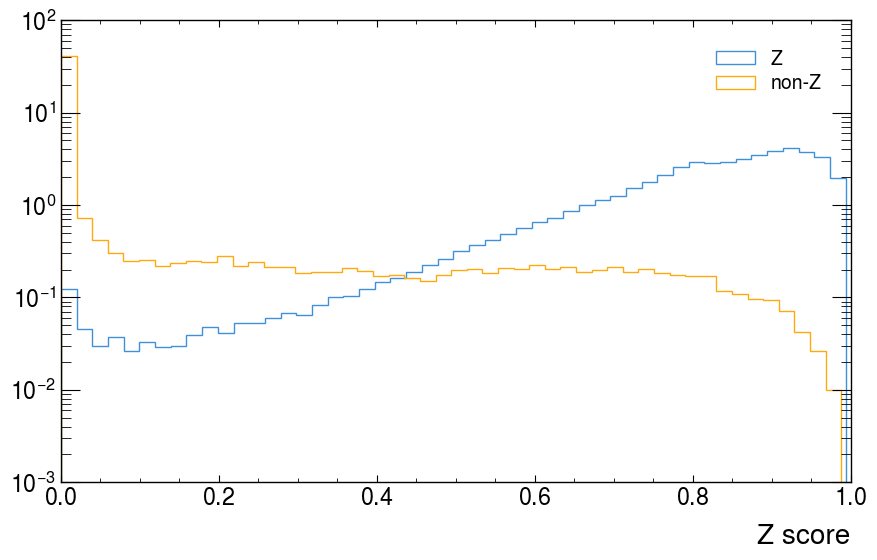

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(score[Data['truth_from_Z'] == True], bins=50, histtype='step', label='Z', density=True)
ax.hist(score[Data['truth_from_Z'] == False], bins=50, histtype='step', label='non-Z', density=True)
ax.legend()
ax.set_yscale('log')
ax.set_xlabel('Z score')

In [10]:
gain_mask = (Data['truth_from_Z'] == True) & (score > cut) & (Data['EventInfo.cutflow'] < 13)
print(f'Z gain: {gain_mask.sum()}')
print(f'actual Zs in data {np.sum(Data["truth_from_Z"] == 1)}')
print(f'relative gain: {gain_mask.sum() / np.sum((Data["truth_from_Z"] == 1) & (Data["EventInfo.cutflow"] < 13))}')

Z gain: 10106
actual Zs in data 178264
relative gain: 0.6318224445139106


In [11]:
print(Data['EventInfo.cutflow_new'][gain_mask].value_counts())

EventInfo.cutflow_new
19    5908
16    2808
17     846
18     442
15     102
Name: count, dtype: int64


In [12]:
print(f'ac')

ac


In [13]:
print(Data['EventInfo.cutflow'][Data['truth_from_Z'] == True].value_counts())
print(Data['EventInfo.cutflow_new'][Data['truth_from_Z'] == True].value_counts())

print(len(Data[(Data['EventInfo.cutflow']!=10) & (Data['truth_from_Z'] == True)])/len(Data[Data['truth_from_Z'] == True]))
num_ATLAS_true = len(Data[(Data['EventInfo.cutflow']!=10) & (Data['truth_from_Z'] == True)])
num_mod_true = len(Data[(Data['EventInfo.cutflow_new']!=0) & (Data['truth_from_Z'] == True)])
print((num_ATLAS_true + num_mod_true)/len(Data[Data['truth_from_Z'] == True]))


EventInfo.cutflow
19    100759
14     43012
10     15995
17      9339
18      8627
15       532
Name: count, dtype: int64
EventInfo.cutflow_new
0     162269
19      8617
16      5056
17      1423
18       671
15       228
Name: count, dtype: int64
0.9102735269039178
1.0


no


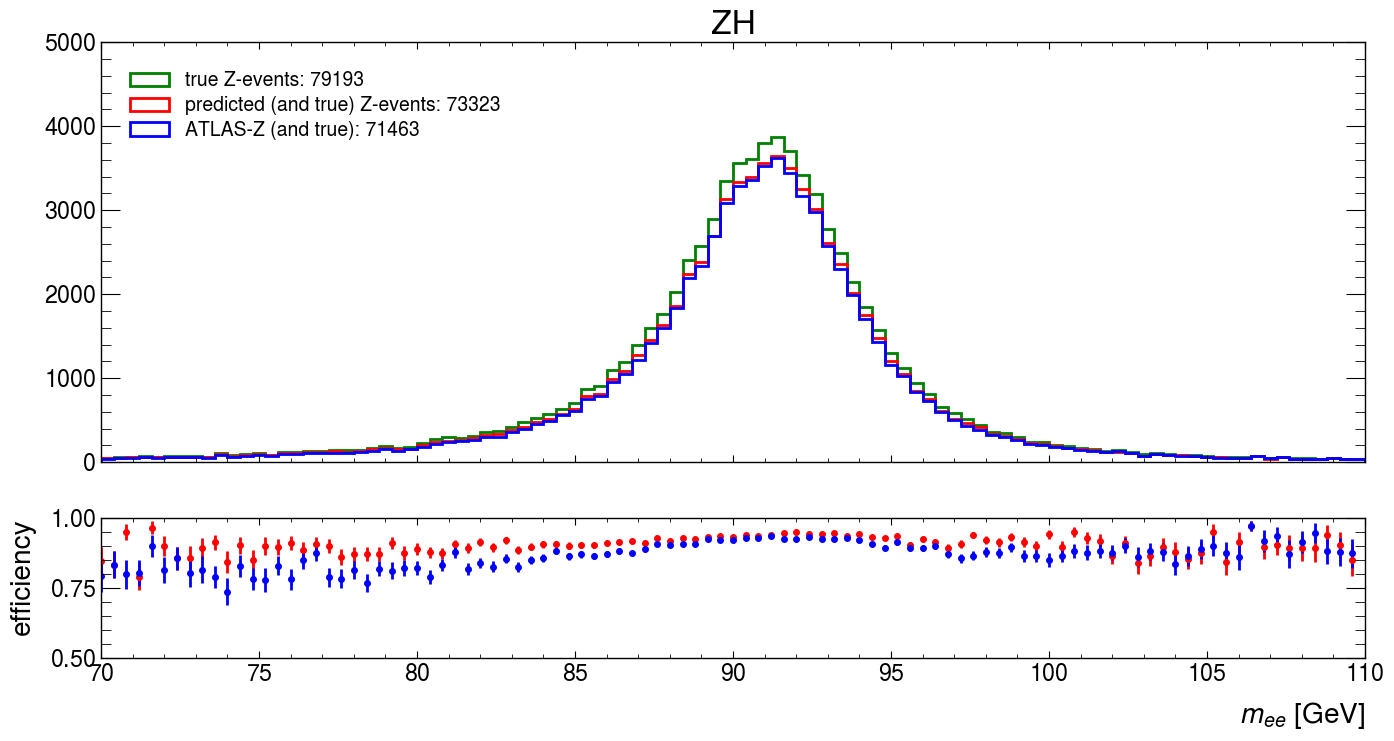

In [14]:
X_test = Data[Data['type'] == 'ZH']

n_bins = 100
y_pred_cut = cut<score[Data['type'] == 'ZH']
fig, ax = plt.subplots(2,1, figsize=(16, 8), height_ratios=[3, 1])
counts_true, bins_true, _ = ax[0].hist(X_test['ll_m'][X_test['truth_from_Z']==1], bins=n_bins, range=(70, 110),linewidth=2, histtype='step', label=f'true Z-events: {np.sum(X_test['truth_from_Z']==1)}', color='green')
counts_trueandmodel, bins_trueandmodel, _ = ax[0].hist(X_test['ll_m'][(y_pred_cut==1) & (X_test['truth_from_Z']==1)], bins=n_bins, range=(70, 110),linewidth=2, histtype='step',color='r', label=f'predicted (and true) Z-events: {np.sum((y_pred_cut==1) & (X_test["truth_from_Z"]==1))}')
counts_trueandATLAS, bins_TrueandATLAS, _ = ax[0].hist(X_test['ll_m'][(X_test['EventInfo.cutflow'] >= 14) & (X_test['truth_from_Z']==1)], bins=n_bins,linewidth=2, range=(70, 110), histtype='step',color='b', label=f'ATLAS-Z (and true): {np.sum((X_test['EventInfo.cutflow'] >= 14) & (X_test["truth_from_Z"]==1))}')
ax[0].legend(loc='upper left')
ax[0].set_xticklabels([])
eff_model = counts_trueandmodel/counts_true
eff_ATLAS = counts_trueandATLAS/counts_true

uncertainty_model = np.sqrt(eff_model*(1-eff_model)/counts_true)
uncertainty_ATLAS = np.sqrt(eff_ATLAS*(1-eff_ATLAS)/counts_true)

ax[1].errorbar(bins_true[:-1], eff_model, yerr=uncertainty_model, fmt='.', label='model', color='r')
ax[1].errorbar(bins_true[:-1], eff_ATLAS, yerr=uncertainty_ATLAS, fmt='.', label='ATLAS', color='b')
ax[1].set_xlabel('$m_{ee}$ [GeV]')
ax[1].set_ylabel('efficiency')
ax[1].set_ylim(0.5,1)

ax[0].set_title('ZH')

# ax[0].set_title('Zee model on Zee data')
# ax[1].legend()

print('no')

no


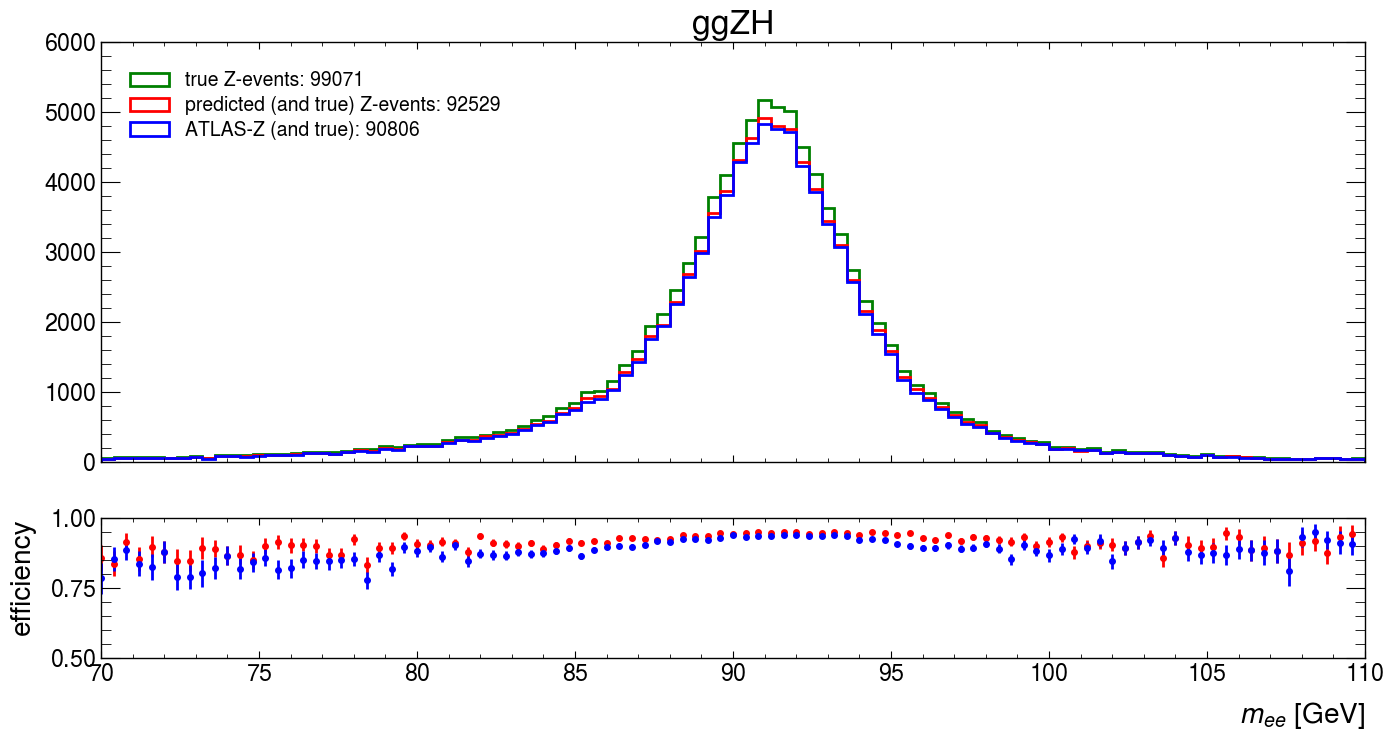

In [15]:
X_test = Data[Data['type'] == 'ggZH']

n_bins = 100
y_pred_cut = cut<score[Data['type'] == 'ggZH']
fig, ax = plt.subplots(2,1, figsize=(16, 8), height_ratios=[3, 1])
counts_true, bins_true, _ = ax[0].hist(X_test['ll_m'][X_test['truth_from_Z']==1], bins=n_bins, range=(70, 110),linewidth=2, histtype='step', label=f'true Z-events: {np.sum(X_test['truth_from_Z']==1)}', color='green')
counts_trueandmodel, bins_trueandmodel, _ = ax[0].hist(X_test['ll_m'][(y_pred_cut==1) & (X_test['truth_from_Z']==1)], bins=n_bins, range=(70, 110),linewidth=2, histtype='step',color='r', label=f'predicted (and true) Z-events: {np.sum((y_pred_cut==1) & (X_test["truth_from_Z"]==1))}')
counts_trueandATLAS, bins_TrueandATLAS, _ = ax[0].hist(X_test['ll_m'][(X_test['EventInfo.cutflow'] >= 14) & (X_test['truth_from_Z']==1)], bins=n_bins,linewidth=2, range=(70, 110), histtype='step',color='b', label=f'ATLAS-Z (and true): {np.sum((X_test['EventInfo.cutflow'] >= 14) & (X_test["truth_from_Z"]==1))}')
ax[0].legend(loc='upper left')
ax[0].set_xticklabels([])
eff_model = counts_trueandmodel/counts_true
eff_ATLAS = counts_trueandATLAS/counts_true

uncertainty_model = np.sqrt(eff_model*(1-eff_model)/counts_true)
uncertainty_ATLAS = np.sqrt(eff_ATLAS*(1-eff_ATLAS)/counts_true)

ax[1].errorbar(bins_true[:-1], eff_model, yerr=uncertainty_model, fmt='.', label='model', color='r')
ax[1].errorbar(bins_true[:-1], eff_ATLAS, yerr=uncertainty_ATLAS, fmt='.', label='ATLAS', color='b')
ax[1].set_xlabel('$m_{ee}$ [GeV]')
ax[1].set_ylabel('efficiency')
ax[1].set_ylim(0.5,1)

ax[0].set_title('ggZH')

# ax[0].set_title('Zee model on Zee data')
# ax[1].legend()

print('no')

no


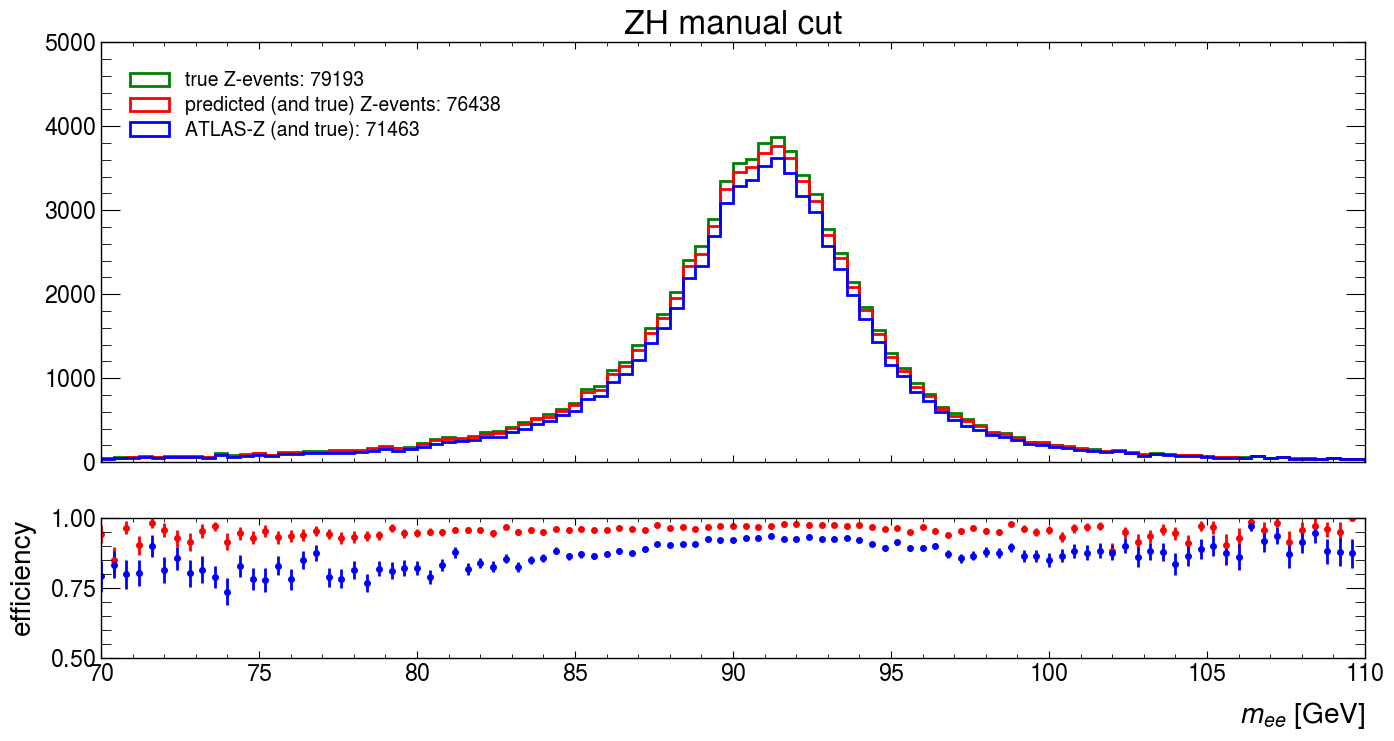

In [16]:
X_test = Data[Data['type'] == 'ZH']

n_bins = 100
y_pred_cut = ((fp2cut+4*cut)/5)<score[Data['type'] == 'ZH']
fig, ax = plt.subplots(2,1, figsize=(16, 8), height_ratios=[3, 1])
counts_true, bins_true, _ = ax[0].hist(X_test['ll_m'][X_test['truth_from_Z']==1], bins=n_bins, range=(70, 110),linewidth=2, histtype='step', label=f'true Z-events: {np.sum(X_test['truth_from_Z']==1)}', color='green')
counts_trueandmodel, bins_trueandmodel, _ = ax[0].hist(X_test['ll_m'][(y_pred_cut==1) & (X_test['truth_from_Z']==1)], bins=n_bins, range=(70, 110),linewidth=2, histtype='step',color='r', label=f'predicted (and true) Z-events: {np.sum((y_pred_cut==1) & (X_test["truth_from_Z"]==1))}')
counts_trueandATLAS, bins_TrueandATLAS, _ = ax[0].hist(X_test['ll_m'][(X_test['EventInfo.cutflow'] >= 14) & (X_test['truth_from_Z']==1)], bins=n_bins,linewidth=2, range=(70, 110), histtype='step',color='b', label=f'ATLAS-Z (and true): {np.sum((X_test['EventInfo.cutflow'] >= 14) & (X_test["truth_from_Z"]==1))}')
ax[0].legend(loc='upper left')
ax[0].set_xticklabels([])
eff_model = counts_trueandmodel/counts_true
eff_ATLAS = counts_trueandATLAS/counts_true

uncertainty_model = np.sqrt(eff_model*(1-eff_model)/counts_true)
uncertainty_ATLAS = np.sqrt(eff_ATLAS*(1-eff_ATLAS)/counts_true)

ax[1].errorbar(bins_true[:-1], eff_model, yerr=uncertainty_model, fmt='.', label='model', color='r')
ax[1].errorbar(bins_true[:-1], eff_ATLAS, yerr=uncertainty_ATLAS, fmt='.', label='ATLAS', color='b')
ax[1].set_xlabel('$m_{ee}$ [GeV]')
ax[1].set_ylabel('efficiency')
ax[1].set_ylim(0.5,1)

ax[0].set_title('ZH manual cut')

# ax[0].set_title('Zee model on Zee data')
# ax[1].legend()

print('no')

no


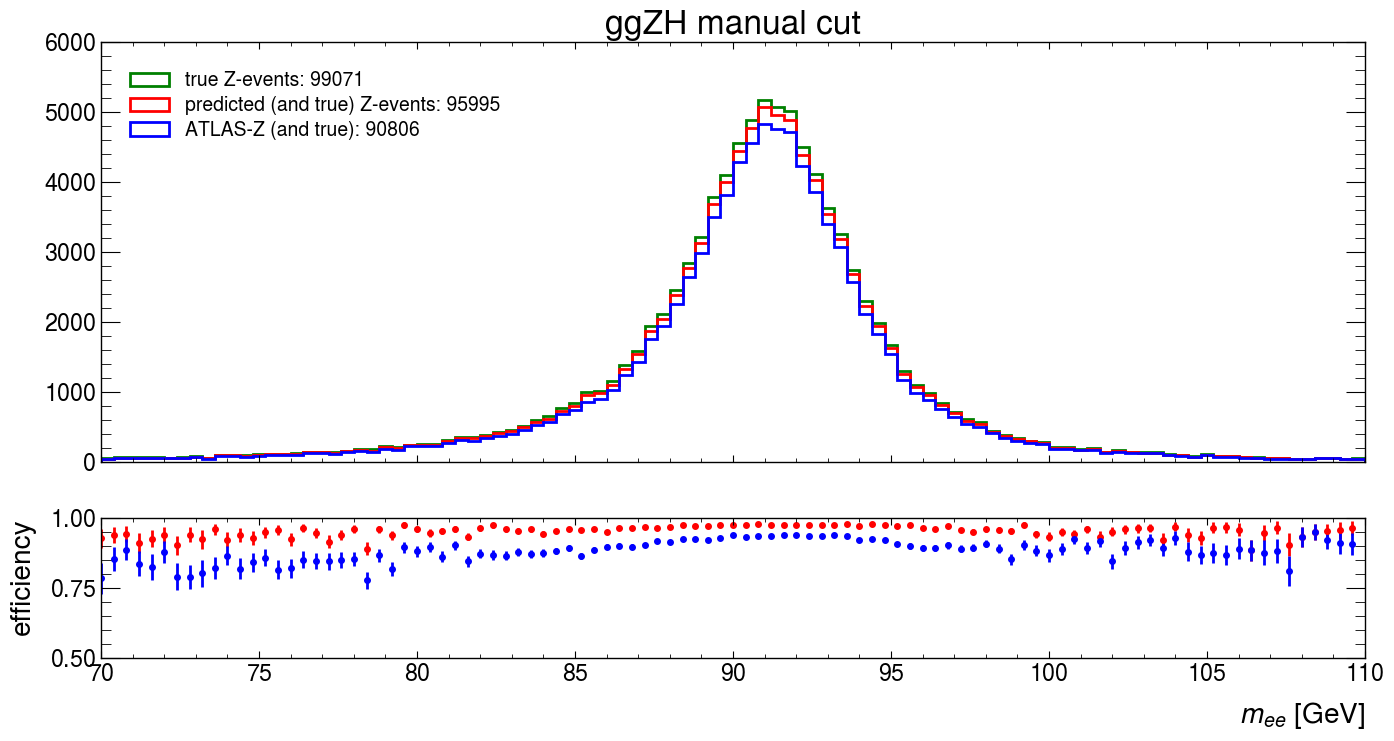

In [17]:
X_test = Data[Data['type'] == 'ggZH']

n_bins = 100
y_pred_cut = ((fp2cut+4*cut)/5)<score[Data['type'] == 'ggZH']
fig, ax = plt.subplots(2,1, figsize=(16, 8), height_ratios=[3, 1])
counts_true, bins_true, _ = ax[0].hist(X_test['ll_m'][X_test['truth_from_Z']==1], bins=n_bins, range=(70, 110),linewidth=2, histtype='step', label=f'true Z-events: {np.sum(X_test['truth_from_Z']==1)}', color='green')
counts_trueandmodel, bins_trueandmodel, _ = ax[0].hist(X_test['ll_m'][(y_pred_cut==1) & (X_test['truth_from_Z']==1)], bins=n_bins, range=(70, 110),linewidth=2, histtype='step',color='r', label=f'predicted (and true) Z-events: {np.sum((y_pred_cut==1) & (X_test["truth_from_Z"]==1))}')
counts_trueandATLAS, bins_TrueandATLAS, _ = ax[0].hist(X_test['ll_m'][(X_test['EventInfo.cutflow'] >= 14) & (X_test['truth_from_Z']==1)], bins=n_bins,linewidth=2, range=(70, 110), histtype='step',color='b', label=f'ATLAS-Z (and true): {np.sum((X_test['EventInfo.cutflow'] >= 14) & (X_test["truth_from_Z"]==1))}')
ax[0].legend(loc='upper left')
ax[0].set_xticklabels([])
eff_model = counts_trueandmodel/counts_true
eff_ATLAS = counts_trueandATLAS/counts_true

uncertainty_model = np.sqrt(eff_model*(1-eff_model)/counts_true)
uncertainty_ATLAS = np.sqrt(eff_ATLAS*(1-eff_ATLAS)/counts_true)

ax[1].errorbar(bins_true[:-1], eff_model, yerr=uncertainty_model, fmt='.', label='model', color='r')
ax[1].errorbar(bins_true[:-1], eff_ATLAS, yerr=uncertainty_ATLAS, fmt='.', label='ATLAS', color='b')
ax[1].set_xlabel('$m_{ee}$ [GeV]')
ax[1].set_ylabel('efficiency')
ax[1].set_ylim(0.5,1)

ax[0].set_title('ggZH manual cut')

# ax[0].set_title('Zee model on Zee data')
# ax[1].legend()

print('no')

f1 ATLAS: 0.9311807360788069, f1 model: 0.9661143341043239
mcc ATLAS: 0.7383918714209082, mcc model: 0.8550150905870405
no


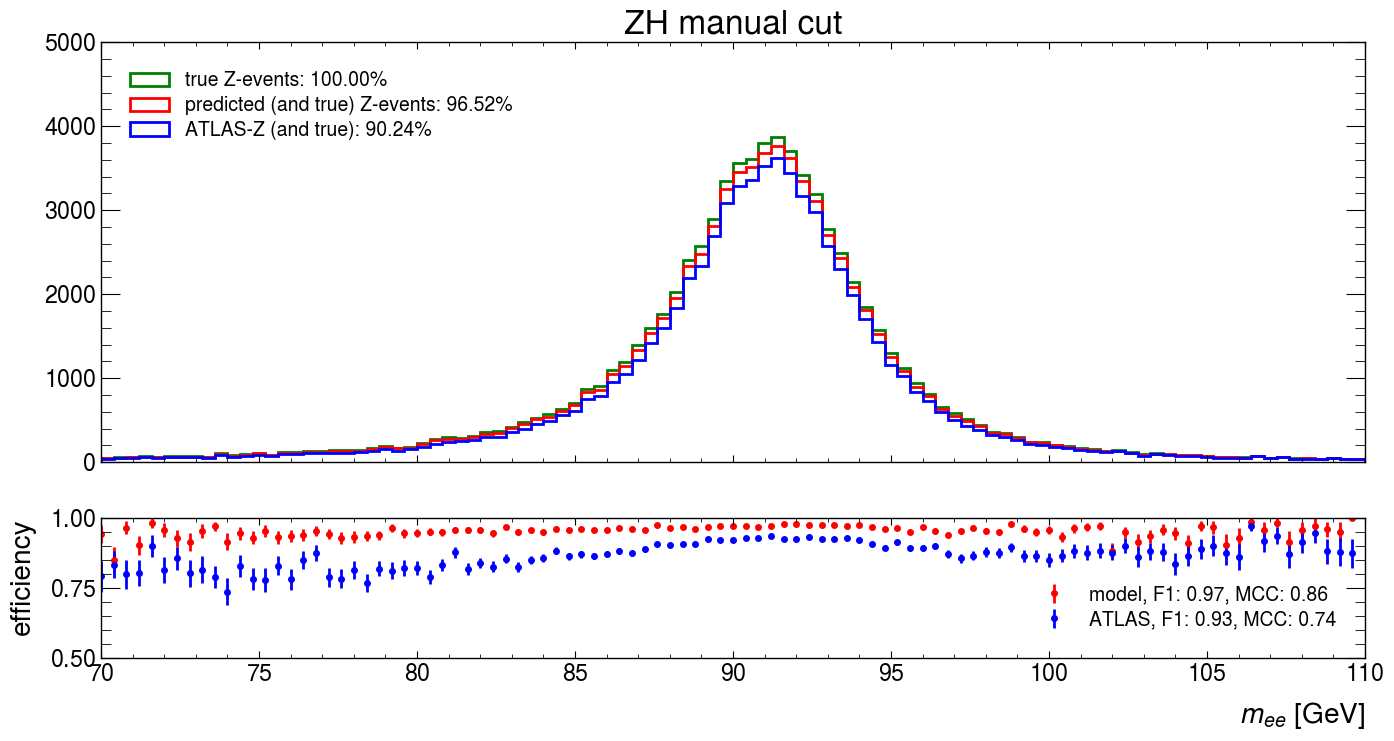

In [18]:
X_test = Data[Data['type'] == 'ZH']

n_bins = 100
y_pred_cut = ((fp2cut+4*cut)/5)<score[Data['type'] == 'ZH']

f1_atlas = f1_score(X_test['truth_from_Z'], X_test['EventInfo.cutflow'] >= 14)
f1_model = f1_score(X_test['truth_from_Z'], y_pred_cut)

mcc_atlas = matthews_corrcoef(X_test['truth_from_Z'], X_test['EventInfo.cutflow'] >= 14)
mcc_model = matthews_corrcoef(X_test['truth_from_Z'], y_pred_cut)

print(f'f1 ATLAS: {f1_atlas}, f1 model: {f1_model}')
print(f'mcc ATLAS: {mcc_atlas}, mcc model: {mcc_model}')


fig, ax = plt.subplots(2,1, figsize=(16, 8), height_ratios=[3, 1])
counts_true, bins_true, _ = ax[0].hist(X_test['ll_m'][X_test['truth_from_Z']==1], bins=n_bins, range=(70, 110),linewidth=2, histtype='step', label=f'true Z-events: {(np.sum(X_test['truth_from_Z']==1)/np.sum(X_test['truth_from_Z']==1))*100:.2f}%', color='green')
counts_trueandmodel, bins_trueandmodel, _ = ax[0].hist(X_test['ll_m'][(y_pred_cut==1) & (X_test['truth_from_Z']==1)], bins=n_bins, range=(70, 110),linewidth=2, histtype='step',color='r', label=f'predicted (and true) Z-events: {(np.sum((y_pred_cut==1) & (X_test["truth_from_Z"]==1)))/np.sum(X_test['truth_from_Z']==1)*100:.2f}%')
counts_trueandATLAS, bins_TrueandATLAS, _ = ax[0].hist(X_test['ll_m'][(X_test['EventInfo.cutflow'] >= 14) & (X_test['truth_from_Z']==1)], bins=n_bins,linewidth=2, range=(70, 110), histtype='step',color='b', label=f'ATLAS-Z (and true): {(np.sum((X_test['EventInfo.cutflow'] >= 14) & (X_test["truth_from_Z"]==1)))/np.sum(X_test['truth_from_Z']==1)*100:.2f}%')
ax[0].legend(loc='upper left')
ax[0].set_xticklabels([])
eff_model = counts_trueandmodel/counts_true
eff_ATLAS = counts_trueandATLAS/counts_true

uncertainty_model = np.sqrt(eff_model*(1-eff_model)/counts_true)
uncertainty_ATLAS = np.sqrt(eff_ATLAS*(1-eff_ATLAS)/counts_true)

ax[1].errorbar(bins_true[:-1], eff_model, yerr=uncertainty_model, fmt='.', label=f'model, F1: {f1_model:.2f}, MCC: {mcc_model:.2f}', color='r')
ax[1].errorbar(bins_true[:-1], eff_ATLAS, yerr=uncertainty_ATLAS, fmt='.', label=f'ATLAS, F1: {f1_atlas:.2f}, MCC: {mcc_atlas:.2f}', color='b')
ax[1].set_xlabel('$m_{ee}$ [GeV]')
ax[1].set_ylabel('efficiency')
ax[1].set_ylim(0.5,1)
ax[1].legend()

ax[0].set_title('ZH manual cut')





print('no')

In [19]:
print((8792502/4)*3)

6594376.5


In [20]:
mask = Data['type'] == 'ggZH'
X_test = Data[mask]

cut = np.linspace(0, 1, 500)

num_sig = np.zeros_like(cut)
num_bkg = np.zeros_like(cut)

for i in range(len(cut)):
    num_sig[i] = np.sum((score[mask] > cut[i]) & X_test['truth_from_Z'])
    num_bkg[i] = np.sum((score[mask] > cut[i]) & ~X_test['truth_from_Z'])

Text(0, 1, 'Background/ATLAS background')

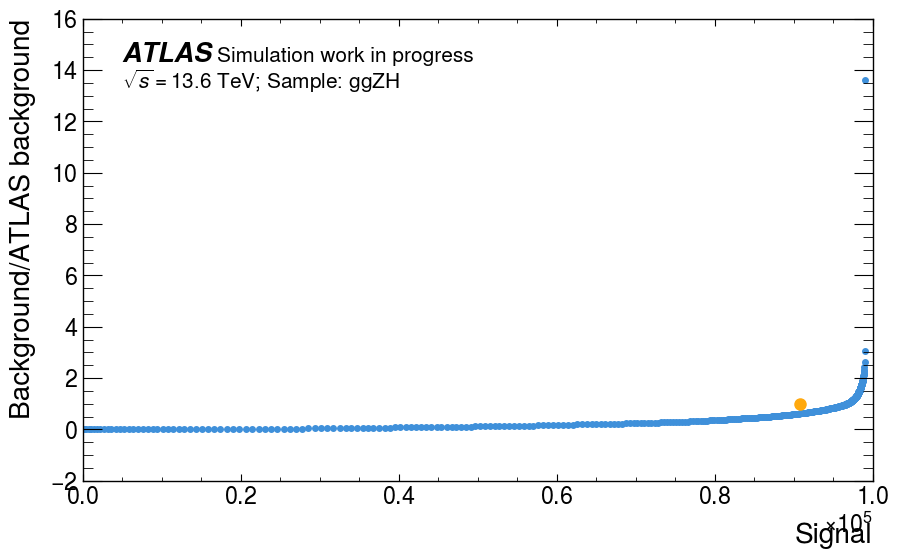

In [21]:
num_sig_atlas = np.sum((X_test['truth_from_Z'] == 1) & (X_test['EventInfo.cutflow'] >= 14))
num_bkg_atlas = np.sum((X_test['truth_from_Z'] == 0) & (X_test['EventInfo.cutflow'] >= 14))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(num_sig, num_bkg/num_bkg_atlas,'.', label='Signal')
ax.plot(num_sig_atlas, num_bkg_atlas/num_bkg_atlas, 'o', label='ATLAS')
# ax.set_xscale('log')
# ax.set_yscale('log')
hep.atlas.label(data=False, label="work in progress", fontsize=15, ax= ax,rlabel=f"$\sqrt{{s}}=13.6$ TeV; Sample: {"ggZH"}")

ax.set_xlabel('Signal')
ax.set_ylabel('Background/ATLAS background')


In [22]:
mask = Data['type'] == 'ZH'
X_test = Data[mask]

cut = np.linspace(0, 1, 500)

num_sig = np.zeros_like(cut)
num_bkg = np.zeros_like(cut)

for i in range(len(cut)):
    num_sig[i] = np.sum((score[mask] > cut[i]) & X_test['truth_from_Z'])
    num_bkg[i] = np.sum((score[mask] > cut[i]) & ~X_test['truth_from_Z'])

(exptext: Custom Text(0.05, 0.95, 'ATLAS'),
 expsuffix: Custom Text(0.05, 0.955, 'Simulation work in progress'),
 supptext: Custom Text(0.05, 0.95, ''),
 expsuffix: Custom Text(0.05, 0.95, '$\\sqrt{s}=13.6$ TeV; Sample: ZH'))

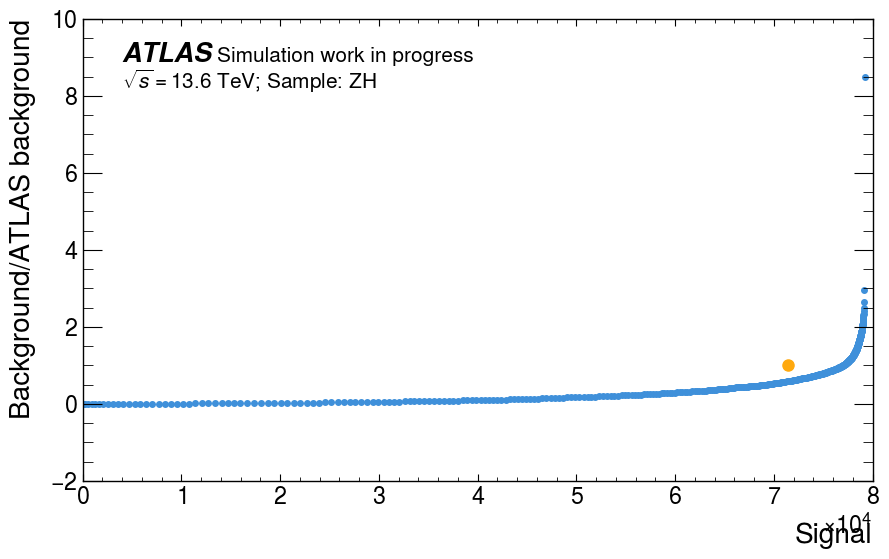

In [ ]:
num_sig_atlas = np.sum((X_test['truth_from_Z'] == 1) & (X_test['EventInfo.cutflow'] >= 14))
num_bkg_atlas = np.sum((X_test['truth_from_Z'] == 0) & (X_test['EventInfo.cutflow'] >= 14))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(num_sig, num_bkg/num_bkg_atlas,'.', label='Signal')
ax.plot(num_sig_atlas, num_bkg_atlas/num_bkg_atlas, 'o', label='ATLAS')
# ax.set_xscale('log')
# ax.set_yscale('log')

ax.set_xlabel('Signal')
ax.set_ylabel('Background/ATLAS background')
hep.atlas.label(data=False, label="work in progress", fontsize=15, ax= ax,rlabel=f"$\sqrt{{s}}=13.6$ TeV; Sample: {"ZH"}")
# ax.legend()


In [ ]:
# lets see where the gains can be made:
True_Z_mask = Data['truth_from_Z'] == True

print(f'gains outside ATLAS cuts: {np.sum(((Data['EventInfo.cutflow'] != 10) | (Data['EventInfo.cutflow'] < 14) ) & True_Z_mask)}')
print(f'gains inside ATLAS cuts: {np.sum((Data['EventInfo.cutflow'] >= 14) & True_Z_mask)}')

gains outside ATLAS cuts: 178264
gains inside ATLAS cuts: 162269


In [29]:
print(Data['EventInfo.cutflow_new'][True_Z_mask].value_counts())
print(Data['EventInfo.cutflow_new'][~True_Z_mask].value_counts())

EventInfo.cutflow_new
0     162269
19      8617
16      5056
17      1423
18       671
15       228
Name: count, dtype: int64
EventInfo.cutflow_new
15    24117
17    13438
16    11700
19     5628
0      5542
18      462
Name: count, dtype: int64
